# Derived Variables

### Core tables (Spark, from the `formula1` database)
- **`drivers`, `laps`, `results`, `session_info`, `session_status`, `track_status`,
  `weather_data`** — one Spark table per raw CSV family, tagged with `year`, `session_number`
  (event/round identifier), and `type_of_race` (`Q` = qualifying, `R` = race) taken from the
  file path.
- **`laps_parsed`** — `laps` with `LapTime`, `PitInTime`, `PitOutTime` converted from
  `"X days HH:MM:SS.ffffff"` strings into numeric seconds (`total_laptime_secs`,
  `pit_in_secs`, `pit_out_secs`).
- **`race_results`** — `results` filtered to `type_of_race == 'R'` (the official race
  classification per driver per event).
- **`quali_results`** — `results` filtered to `type_of_race == 'Q'`, renamed so `Position`
  becomes `quali_pos`.
- **`overtakes_spark`** — one row per `year, session_number, DriverNumber` with
  `overtakes_made`, counted by comparing each lap's `Position` to the previous lap's
  `Position` (a decrease = a pass) within `laps_parsed`, race laps only.
- **`best_pit_spark`** — one row per `year, session_number, DriverNumber` with
  `best_pit_sec`, the driver's fastest pit-stop (in-lap `pit_in_secs` paired with the very
  next out-lap's `pit_out_secs`, minimum duration per driver per event).
- **`fastest_lap_spark`** — one row per `year, session_number, DriverNumber` with
  `fastest_lap_flag = 1` for whoever set the quickest `total_laptime_secs` in that race.
- **`master_spark`** — the join of all of the above onto `race_results`, plus the computed
  point columns: **`pts_race`, `pts_quali`, `pts_pos`, `pts_overtake`, `pts_fastest`,
  `fantasy_pts_total`** (`fantasy_pts_total` is the sum of the five `pts_*` columns).
- **`master_features_spark`** — `master_spark` with rolling/form features added:
  **`prev_race_pts`, `rolling_3_avg`, `rolling_5_avg`, `form_momentum`, `pace_gap_pct`,
  `laptime_cv`, `pit_stop_count`, `avg_race_position`, `grid_pct`, `scored_points`,
  `is_podium`, `positions_gained`, `positions_lost`, `pts_per_grid_spot`**.


# Possible for variables for modeling
- `GridPosition` / `grid_pct` — qualifying performance is one of the five scoring
  components (`pts_quali`) and also bounds how much a driver *can* gain (`positions_gained`).
- `positions_gained` / `overtakes_made` — directly scored via `pts_pos` and `pts_overtake`;
  visual 8 (grid vs. avg positions gained/lost) should show whether this is more a function of
  starting position or of driver/car skill.
- `is_podium`, `avg_race_position` — closely track `pts_race`, the largest single component
  in most fantasy formulas.
- `fastest_lap_flag` — a fixed bonus (`pts_fastest`), low-frequency but high-signal for the
  driver who earns it.
- `rolling_3_avg` / `rolling_5_avg` / `prev_race_pts` — recent form is a common predictor in
  fantasy sports; watch visual 16 (rolling-form hexbin) for how tight this relationship is.
- `form_momentum` — whether a driver is trending up or down relative to their own recent
  average; likely more useful for week-to-week prediction than season-long averages.
- `pace_gap_pct` / `laptime_cv` — how close to the field's fastest lap a driver ran, and how
  consistent their own lap times were; visual 17 should show whether erratic lap times
  (`>5%` CV) correspond to worse fantasy outcomes.
- `pit_stop_count` — more pit stops can mean more strategic overtaking opportunity, but also
  more time lost; the boxplot in visual 17 should clarify which effect dominates.
- `TeamName` — team strength is a real effect (see visual 6, pit stop times, and visual 11,
  teammate head-to-head) but is more of a grouping variable than a numeric predictor; consider
  a team-strength index (e.g. season-to-date average finishing position by team) rather than
  the raw name.
- `best_pit_sec` — matters more for identifying *strategic* misses (a slow stop that costs a
  position) than as a direct linear predictor of points.


**Recommended starting feature set for a first model**, in priority order: `GridPosition`,
`rolling_3_avg`, `avg_race_position`, `pace_gap_pct`, `positions_gained` (or `overtakes_made`
if you want the on-track-passing signal specifically, since the two are correlated),
`is_podium`, `fastest_lap_flag`, `laptime_cv`, `pit_stop_count`, `form_momentum`. Drop
`positions_gained` and `overtakes_made` together in the same model only if you first check
their correlation with each other in visual 18 — they're likely to be highly collinear.





Bringing in data

In [9]:
# ── Spark session ─────────────────────────────────────────────────────────────
# Same session config as both source notebooks: LEGACY time parser policy is needed
# because some of the raw date/time strings in these CSVs use formats the modern
# Spark time parser rejects.
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, lit, input_file_name, regexp_extract, length
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .appName("F1_Fantasy_AllYears")
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")


In [10]:
# Reads every CSV under data_raw_path/<year>/session_<n>_<type>/<file_name>.csv in one
# shot (the `*` wildcards do the "all years, all events" work), then parses three pieces
# of metadata straight out of the file path:
#   - year            e.g. 2018, 2019, 2021, ...
#   - session_number  the event/round number within that year
#   - type_of_race    'Q' (qualifying) or 'R' (race), parsed from the folder name
data_raw_path = "/home/ukr2xt/Formula-1/data/data_raw"

def load_files(file_name):
    """Read one CSV family (drivers/laps/results/etc.) across every year and session,
    and tag each row with year / session_number / type_of_race parsed from its path."""
    base_path = f"{data_raw_path}/*/session_*/{file_name}.csv"

    df = spark.read.csv(base_path, header=True, inferSchema=True)

    file_path = input_file_name()
    df = (
        df
        .withColumn("source_file", file_path)
        .withColumn("year", regexp_extract(col("source_file"), r"data_raw/(\d{4})/", 1).cast("int"))
        .withColumn("session_number", regexp_extract(col("source_file"), r"session_(\d+)", 1).cast("int"))
        .withColumn("type_of_race", regexp_extract(col("source_file"), r"session_\d+_?(\w*)", 1).cast("string"))
        .drop("_c0")  # pandas-style index column baked into the CSV export, not real data
    )
    return df


In [12]:
# Drop the database and all tables inside it
spark.sql("DROP DATABASE IF EXISTS formula1 CASCADE")

# Recreate the database
spark.sql("CREATE DATABASE formula1")

# Switch into it
spark.sql("USE formula1")


file_names = [
    "drivers", "laps", "results", "session_info",
    "session_status", "track_status", "weather_data",
]

raw_tables = {}
for name in file_names:
    raw_tables[name] = load_files(name)
    raw_tables[name].write.mode("overwrite").saveAsTable(f"formula1.{name}")
    print(f"✓ loaded and saved formula1.{name}")


spark.sql("SHOW TABLES").show()






✓ loaded and saved formula1.drivers


✓ loaded and saved formula1.laps


✓ loaded and saved formula1.results
✓ loaded and saved formula1.session_info
✓ loaded and saved formula1.session_status


✓ loaded and saved formula1.track_status
✓ loaded and saved formula1.weather_data
+---------+--------------+-----------+
|namespace|     tableName|isTemporary|
+---------+--------------+-----------+
| formula1|       drivers|      false|
| formula1|          laps|      false|
| formula1|       results|      false|
| formula1|  session_info|      false|
| formula1|session_status|      false|
| formula1|  track_status|      false|
| formula1|  weather_data|      false|
+---------+--------------+-----------+



In [13]:
# ── Fix the drivers table's unlabeled driver-number column ────────────────────
# The raw CSV export leaves the driver number column named "0" (a pandas artifact).
# Only rename it if that's actually the situation, so this cell is safe to re-run.
drivers = spark.table("formula1.drivers")
if "0" in drivers.columns:
    drivers = drivers.withColumnRenamed("0", "driver_number")
    drivers.write.mode("overwrite").saveAsTable("formula1.drivers_fixed")
    spark.sql("DROP TABLE formula1.drivers")
    spark.sql("ALTER TABLE formula1.drivers_fixed RENAME TO formula1.drivers")
    drivers = spark.table("formula1.drivers")

drivers.show(5)

+-------------+--------------------+----+--------------+------------+
|driver_number|         source_file|year|session_number|type_of_race|
+-------------+--------------------+----+--------------+------------+
|           63|file:///home/ukr2...|2026|             7|           Q|
|           44|file:///home/ukr2...|2026|             7|           Q|
|           12|file:///home/ukr2...|2026|             7|           Q|
|            1|file:///home/ukr2...|2026|             7|           Q|
|            3|file:///home/ukr2...|2026|             7|           Q|
+-------------+--------------------+----+--------------+------------+
only showing top 5 rows


In [ ]:
## 2. Parsing Lap, Pit-In, and Pit-Out Times

The raw `LapTime`, `PitInTime`, and `PitOutTime` columns come in as pandas timedelta strings (`"0 days 00:01:23.456000"`). `f1.ipynb` converted these using pandas before loading into Spark; the database approach needs to do the equivalent conversion *inside* Spark with regex, since the raw CSVs are read directly. The regex logic here is the working parser from `spark_checker.ipynb` (cell that produced `total_laptime_secs`), generalized into one reusable helper so it can also parse `PitInTime` / `PitOutTime` without duplicating the regex three times.

In [14]:
# ── Reusable timedelta-string -> seconds parser ───────────────────────────────
# Works on any column formatted like "0 days 00:01:23.456000". Only fills in a
# piece (days/minutes/seconds) if that piece's regex actually matched, so rows
# with no pit stop (nulls) correctly stay null all the way through.
def timedelta_str_to_seconds(colname):
    days = when(
        length(regexp_extract(col(colname), r"(\d+) days", 1)) > 0,
        regexp_extract(col(colname), r"(\d+) days", 1).cast("int")
    )
    minutes = when(
        length(regexp_extract(col(colname), r"days \d{2}:(\d{2}):", 1)) > 0,
        regexp_extract(col(colname), r"days \d{2}:(\d{2}):", 1).cast("int")
    )
    seconds = when(
        length(regexp_extract(col(colname), r"days \d{2}:\d{2}:(\d{2}\.\d+)", 1)) > 0,
        regexp_extract(col(colname), r"days \d{2}:\d{2}:(\d{2}\.\d+)", 1).cast("double")
    )
    # days * 86400 (seconds/day) + minutes * 60 + seconds
    return days * 86400 + minutes * 60 + seconds

laps_raw = spark.table("formula1.laps")

laps_parsed = (
    laps_raw
    .withColumn("total_laptime_secs", timedelta_str_to_seconds("LapTime"))
    .withColumn("pit_in_secs",  timedelta_str_to_seconds("PitInTime"))
    .withColumn("pit_out_secs", timedelta_str_to_seconds("PitOutTime"))
)

# Persist the parsed version back to the database so downstream queries can just
# read formula1.laps directly (mirrors what spark_checker.ipynb did).
laps_parsed.write.mode("overwrite").saveAsTable("formula1.laps_parsed")
laps_parsed.select("Driver", "LapNumber", "LapTime", "total_laptime_secs",
                    "pit_in_secs", "pit_out_secs").show(10)


+------+---------+--------------------+------------------+-----------+------------+
|Driver|LapNumber|             LapTime|total_laptime_secs|pit_in_secs|pit_out_secs|
+------+---------+--------------------+------------------+-----------+------------+
|   GAS|      1.0|0 days 00:01:22.8...| 82.82300000000001|       NULL|        NULL|
|   GAS|      2.0|0 days 00:01:33.5...|            93.553|       NULL|        NULL|
|   GAS|      3.0|0 days 00:01:31.4...| 91.40899999999999|       NULL|        NULL|
|   GAS|      4.0|0 days 00:01:29.5...|            89.513|       NULL|        NULL|
|   GAS|      5.0|0 days 00:01:32.3...|            92.311|       NULL|        NULL|
|   GAS|      6.0|0 days 00:01:21.4...| 81.47200000000001|       NULL|        NULL|
|   GAS|      7.0|0 days 00:00:59.5...|            59.592|       NULL|        NULL|
|   GAS|      8.0|0 days 00:00:59.3...|            59.323|       NULL|        NULL|
|   GAS|      9.0|0 days 00:00:58.9...|            58.997|       NULL|      

In [ ]:
## 3. Building the Fantasy-Points Components

This section rebuilds `f1.ipynb`'s detailed, component-based formula (`pts_race`, `pts_quali`, `pts_pos`, `pts_overtake`, `pts_fastest`) but sources every input from the `formula1` database instead of the FastF1 API, and runs it across every season present in the data (not just 2018–2019). The scoring tables (`RACE_PTS`, `QUALI_PTS`) and the bonus values for overtakes and fastest lap are the same shape as `f1.ipynb`'s working formula — adjust the constants as necessary!! hannah took liberties here.

In [15]:
# ── Split results into race and qualifying classifications ────────────────────
# type_of_race was parsed from the folder name during ingestion ('R' vs 'Q').
# Two events (year, session_number) can share the same DriverNumber, so that's
# the join key used throughout this section.
results = spark.table("formula1.results")

race_results = results.filter(col("type_of_race") == "R")

quali_results = (
    results
    .filter(col("type_of_race") == "Q")
    .select("year", "session_number", "DriverNumber",
            col("Position").alias("quali_pos"))
)
quali_results = quali_results.withColumn("quali_pos", col("quali_pos").cast("int"))




# ── Overtakes: count every lap-to-lap position improvement during the race ────
# Same logic as f1.ipynb's cell 4, generalized to (year, session_number) instead
# of (year, round) since that's how events are keyed in the database.
race_laps = (
    laps_parsed
    .filter(col("type_of_race") == "R")
    .withColumn("Position", col("Position").cast("int"))
)

overtake_window = Window.partitionBy("year", "session_number", "DriverNumber").orderBy("LapNumber")

overtakes_spark = (
    race_laps
    .withColumn("prev_position", F.lag("Position", 1).over(overtake_window))
    .withColumn(
        "overtake_this_lap",
        when(col("prev_position").isNotNull() & (col("Position") < col("prev_position")), 1).otherwise(0)
    )
    .groupBy("year", "session_number", "DriverNumber")
    .agg(F.sum("overtake_this_lap").alias("overtakes_made"))
)

overtakes_spark.orderBy(F.desc("overtakes_made")).show(5)


# ── Best pit-stop duration per driver per race ─────────────────────────────────
# Same in-lap / out-lap pairing logic as f1.ipynb's cell 5: an in-lap (where the
# driver entered the pits) is paired with the *next* out-lap (where they left)
# for that same driver in that same race, and the duration is out_time - in_time.
# best_pit_sec is deliberately left null (not filled with 0) when a driver never
# pitted or retired mid-pit-entry — null correctly means "no valid stop to report."
in_laps = (
    race_laps
    .filter(col("pit_in_secs").isNotNull())
    .select("year", "session_number", "DriverNumber", "LapNumber",
            col("pit_in_secs").alias("pit_in_time"))
)

out_laps = (
    race_laps
    .filter(col("pit_out_secs").isNotNull())
    .select("year", "session_number", "DriverNumber", "LapNumber",
            col("pit_out_secs").alias("pit_out_time"))
)

paired_pits = (
    in_laps.alias("i")
    .join(
        out_laps.alias("o"),
        (col("i.year") == col("o.year")) &
        (col("i.session_number") == col("o.session_number")) &
        (col("i.DriverNumber") == col("o.DriverNumber")) &
        (col("o.pit_out_time") > col("i.pit_in_time")),
        how="inner",
    )
    .withColumn("pit_duration_sec", col("o.pit_out_time") - col("i.pit_in_time"))
)

best_pit_spark = (
    paired_pits
    .groupBy(col("i.year").alias("year"), col("i.session_number").alias("session_number"),
              col("i.DriverNumber").alias("DriverNumber"))
    .agg(F.min("pit_duration_sec").alias("best_pit_sec"))
)

# ── Fastest lap flag: whoever set the quickest race lap in each event ─────────
fastest_lap_window = Window.partitionBy("year", "session_number").orderBy("total_laptime_secs")

fastest_lap_spark = (
    race_laps
    .filter(col("total_laptime_secs").isNotNull())
    .withColumn("rnk", F.rank().over(fastest_lap_window))
    .filter(col("rnk") == 1)
    .select("year", "session_number", "DriverNumber")
    .withColumn("fastest_lap_flag", F.lit(1))
)


# ── Point value constants ──────────────────────────────────────────────────────
### hannah note: took some liberties and assigned points here
# Standard F1-style points-paying positions, same tables as f1.ipynb.
RACE_PTS  = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}
QUALI_PTS = {1: 10, 2: 9,  3: 8,  4: 7,  5: 6,  6: 5, 7: 4, 8: 3, 9: 2, 10: 1}

# NOTE: f1.ipynb's source cells were cut off before showing the exact multiplier
# used for pts_overtake and pts_fastest. These are set to a sensible default
# (1 point per overtake, 5 points for fastest lap) — change PTS_PER_OVERTAKE /
# FASTEST_LAP_BONUS below.
PTS_PER_OVERTAKE  = 1
FASTEST_LAP_BONUS = 5

def position_to_points(col_name, pts_dict):
    """Map a position column to fantasy points using a lookup dict; unranked = 0."""
    expr = None
    for pos, pts in pts_dict.items():
        expr = when(col(col_name) == pos, pts) if expr is None else expr.when(col(col_name) == pos, pts)
    return expr.otherwise(0)




+----+--------------+------------+--------------+
|year|session_number|DriverNumber|overtakes_made|
+----+--------------+------------+--------------+
|2022|             1|          24|            22|
|2023|             7|          16|            21|
|2023|            17|          11|            21|
|2022|            11|          14|            20|
|2023|            17|          63|            20|
+----+--------------+------------+--------------+
only showing top 5 rows


In [16]:
# ── Join everything onto the race results and compute the fantasy formula ─────
master_spark = (
    race_results
    .join(quali_results,      on=["year", "session_number", "DriverNumber"], how="left")
    .join(overtakes_spark,    on=["year", "session_number", "DriverNumber"], how="left")
    .join(best_pit_spark,     on=["year", "session_number", "DriverNumber"], how="left")
    .join(fastest_lap_spark,  on=["year", "session_number", "DriverNumber"], how="left")
    .fillna({"overtakes_made": 0, "fastest_lap_flag": 0})
    # best_pit_sec is intentionally NOT filled — null means "no valid pit stop", not zero seconds
)

master_spark = (
    master_spark
    .withColumn("Position",     col("Position").cast("int"))
    .withColumn("GridPosition", col("GridPosition").cast("int"))
    .withColumn("pts_race",         position_to_points("Position", RACE_PTS))
    .withColumn("pts_quali",        position_to_points("quali_pos", QUALI_PTS))
    .withColumn("positions_gained", col("GridPosition") - col("Position"))
    .withColumn("pts_pos",          col("positions_gained") * 2)
    .withColumn("pts_overtake",     col("overtakes_made") * PTS_PER_OVERTAKE)
    .withColumn("pts_fastest",      col("fastest_lap_flag") * FASTEST_LAP_BONUS)
    .withColumn(
        "fantasy_pts_total",
        col("pts_race") + col("pts_quali") + col("pts_pos") + col("pts_overtake") + col("pts_fastest")
    )
)

master_spark.select(
    "year", "session_number", "DriverNumber", "Abbreviation", "TeamName",
    "pts_race", "pts_quali", "pts_pos", "pts_overtake", "pts_fastest", "fantasy_pts_total"
).orderBy(F.desc("fantasy_pts_total")).show(10)

# Persist as a queryable table too, mirroring the "write master to the database" step
# f1.ipynb did with parquet — here it goes into the same Spark SQL database instead.
(
    master_spark
    .repartition("year")
    .write.mode("overwrite")
    .partitionBy("year")
    .saveAsTable("formula1.master")
)

+----+--------------+------------+------------+---------------+--------+---------+-------+------------+-----------+-----------------+
|year|session_number|DriverNumber|Abbreviation|       TeamName|pts_race|pts_quali|pts_pos|pts_overtake|pts_fastest|fantasy_pts_total|
+----+--------------+------------+------------+---------------+--------+---------+-------+------------+-----------+-----------------+
|2022|            14|           1|         VER|Red Bull Racing|      25|       10|     26|           7|          5|               73|
|2021|            15|          33|         VER|Red Bull Racing|      18|        0|     36|          18|          0|               72|
|2024|            21|           1|         VER|Red Bull Racing|      25|        0|     32|           9|          5|               71|
|2021|            14|          77|         BOT|       Mercedes|      15|       10|     32|          13|          0|               70|
|2025|            21|           1|         VER|Red Bull Racing

In [ ]:
# addl feature engineering !

In [18]:
# ── Per-race lap-based features (pace, consistency, pit stops) ────────────────
race_laps_clean = race_laps.filter(col("total_laptime_secs") > 0)

session_fastest = (
    race_laps_clean
    .groupBy("year", "session_number")
    .agg(F.min("total_laptime_secs").alias("session_fastest_laptime"))
)

lap_features = (
    race_laps_clean
    .groupBy("year", "session_number", "DriverNumber")
    .agg(
        F.mean("total_laptime_secs").alias("avg_laptime_secs"),
        F.stddev("total_laptime_secs").alias("laptime_std"),
        F.count("*").alias("laps_completed"),
        F.mean("Position").alias("avg_race_position"),
        F.sum(when(col("pit_out_secs").isNotNull(), 1).otherwise(0)).alias("pit_stop_count"),
    )
    .join(session_fastest, on=["year", "session_number"], how="left")
    # pace_gap_pct: how far off the fastest lap of the race this driver's average lap was
    .withColumn("pace_gap_pct",
        (col("avg_laptime_secs") - col("session_fastest_laptime")) / col("session_fastest_laptime") * 100)
    # laptime_cv: coefficient of variation — lower means more consistent lap times
    .withColumn("laptime_cv", col("laptime_std") / col("avg_laptime_secs") * 100))

In [19]:
# ── Rolling form features (per driver, ordered by year then event) ────────────
# rowsBetween(-3, -1) / (-5, -1) means "the 3 (or 5) races before this one" —
# using .orderBy without the current row, so this never leaks the current
# race's own result into its own rolling average.
driver_window = Window.partitionBy("DriverNumber").orderBy("year", "session_number")

master_features_spark = (
    master_spark
    .withColumn("is_podium",     when(col("Position") <= 3, 1).otherwise(0))
    .withColumn("scored_points", when(col("pts_race") > 0, 1).otherwise(0))
    .withColumn("grid_pct",      (col("GridPosition") - 1) / 19.0)
    .withColumn("positions_lost", when(col("positions_gained") < 0, -col("positions_gained")).otherwise(0))
    .withColumn("pts_per_grid_spot", col("fantasy_pts_total") / (col("GridPosition") + 0.1))
    .withColumn("prev_race_pts", F.lag("fantasy_pts_total", 1).over(driver_window))
    .withColumn("rolling_3_avg", F.avg("fantasy_pts_total").over(driver_window.rowsBetween(-3, -1)))
    .withColumn("rolling_5_avg", F.avg("fantasy_pts_total").over(driver_window.rowsBetween(-5, -1)))
    .withColumn("form_momentum", col("prev_race_pts") - F.avg("fantasy_pts_total").over(driver_window.rowsBetween(-5, -1)))
    .join(
        lap_features.select("year", "session_number", "DriverNumber", "avg_laptime_secs",
                             "laptime_cv", "laps_completed", "avg_race_position",
                             "pit_stop_count", "pace_gap_pct"),
        on=["year", "session_number", "DriverNumber"], how="left",
    )
)

master_features_spark.write.mode("overwrite").saveAsTable("formula1.master_features")
print("master_features_spark columns:", master_features_spark.columns)


master_features_spark columns: ['year', 'session_number', 'DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName', 'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName', 'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition', 'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps', 'source_file', 'type_of_race', 'quali_pos', 'overtakes_made', 'best_pit_sec', 'fastest_lap_flag', 'pts_race', 'pts_quali', 'positions_gained', 'pts_pos', 'pts_overtake', 'pts_fastest', 'fantasy_pts_total', 'is_podium', 'scored_points', 'grid_pct', 'positions_lost', 'pts_per_grid_spot', 'prev_race_pts', 'rolling_3_avg', 'rolling_5_avg', 'form_momentum', 'avg_laptime_secs', 'laptime_cv', 'laps_completed', 'avg_race_position', 'pit_stop_count', 'pace_gap_pct']


# pulling into pandas 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Pull the full feature table to pandas ──────────────────────────────────────
master_pd = master_features_spark.toPandas()

numeric_cols = [
    "Position", "GridPosition", "quali_pos", "positions_gained", "positions_lost",
    "overtakes_made", "best_pit_sec", "fastest_lap_flag", "is_podium", "scored_points",
    "grid_pct", "pts_per_grid_spot", "prev_race_pts", "rolling_3_avg", "rolling_5_avg",
    "form_momentum", "avg_laptime_secs", "laptime_cv", "laps_completed",
    "avg_race_position", "pit_stop_count", "pace_gap_pct",
    "pts_race", "pts_quali", "pts_pos", "pts_overtake", "pts_fastest",
    "fantasy_pts_total", "year", "session_number",
]
for c in numeric_cols:
    if c in master_pd.columns:
        master_pd[c] = pd.to_numeric(master_pd[c], errors="coerce")

driver_col = "Abbreviation" if "Abbreviation" in master_pd.columns else "DriverNumber"
team_col   = "TeamName" if "TeamName" in master_pd.columns else ("Team" if "Team" in master_pd.columns else None)

print(f"Master dataset: {len(master_pd):,} rows x {len(master_pd.columns)} columns")
print(master_pd[[driver_col, "year", "session_number", "fantasy_pts_total"]].head(10))

Master dataset: 2,772 rows x 52 columns
  Abbreviation  year  session_number  fantasy_pts_total
0          VER  2022               1              -22.0
1          VER  2022               2               41.0
2          VER  2022               3              -19.0
3          VER  2022               4               40.0
4          VER  2022               5               44.0
5          VER  2022               6               44.0
6          VER  2022               7               26.0
7          VER  2022               8               40.0
8          VER  2022               9               38.0
9          VER  2022              10               10.0


In [21]:
# checking things

print("── Null audit ──────────────────────────────")
key_cols = ["Position", "GridPosition", "quali_pos", "positions_gained",
            "overtakes_made", "best_pit_sec", "fastest_lap_flag", "fantasy_pts_total"]
key_cols = [c for c in key_cols if c in master_pd.columns]
null_pct = (master_pd[key_cols].isna().mean() * 100).round(1)
print(null_pct.to_string())

print("\n── Fantasy points summary by year ──────────")
print(master_pd.groupby("year")["fantasy_pts_total"].describe().round(2))

print("\n── Unique drivers per year ─────────────────")
print(master_pd.groupby("year")[driver_col].nunique())

── Null audit ──────────────────────────────
Position              0.1
GridPosition          0.1
quali_pos            31.2
positions_gained      0.1
overtakes_made        0.0
best_pit_sec          7.3
fastest_lap_flag      0.0
fantasy_pts_total     0.1

── Fantasy points summary by year ──────────
      count   mean    std   min  25%   50%   75%   max
year                                                  
2020  340.0  13.96  16.63 -36.0  4.0  15.0  26.0  57.0
2021  439.0  12.78  16.29 -40.0  3.5  13.0  23.0  72.0
2022  439.0  14.07  17.60 -31.0  4.0  15.0  26.0  73.0
2023  439.0  12.80  15.96 -36.0  3.0  14.0  22.0  58.0
2024  479.0  11.69  13.23 -36.0  4.0  12.0  20.0  71.0
2025  479.0  14.72  15.22 -24.0  5.0  15.0  25.0  66.0
2026  154.0  12.30  16.39 -31.0  4.0  14.0  24.0  51.0

── Unique drivers per year ─────────────────
year
2020    23
2021    21
2022    22
2023    22
2024    24
2025    21
2026    22
Name: Abbreviation, dtype: int64


In [ ]:
# alrighty this is a little extra - will drop later

In [23]:
# ── Shared styling (F1 dark theme) used by every chart below ───────────────────
F1_RED   = "#E10600"
F1_AMBER = "#FF8000"
F1_BLUE  = "#00A1E0"
F1_WHITE = "#ffffff"
F1_DARK  = "#1f1f2e"

available_years = sorted(master_pd["year"].dropna().unique().astype(int))
base_colors = [F1_RED, F1_BLUE, F1_AMBER, "#00c853", "#a855f7", "#228B22", "#FF69B4"]
YEAR_COLORS = {yr: base_colors[i % len(base_colors)] for i, yr in enumerate(available_years)}
colors_cycle = base_colors

plt.rcParams.update({
    "figure.facecolor": F1_DARK, "axes.facecolor": F1_DARK,
    "text.color": F1_WHITE, "axes.labelcolor": F1_WHITE,
    "xtick.color": F1_WHITE, "ytick.color": F1_WHITE,
    "grid.color": "#333344", "legend.facecolor": "#2a2a3e",
})

viz 1: per race fantasy points distr

/tmp/ipykernel_187398/1682434698.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


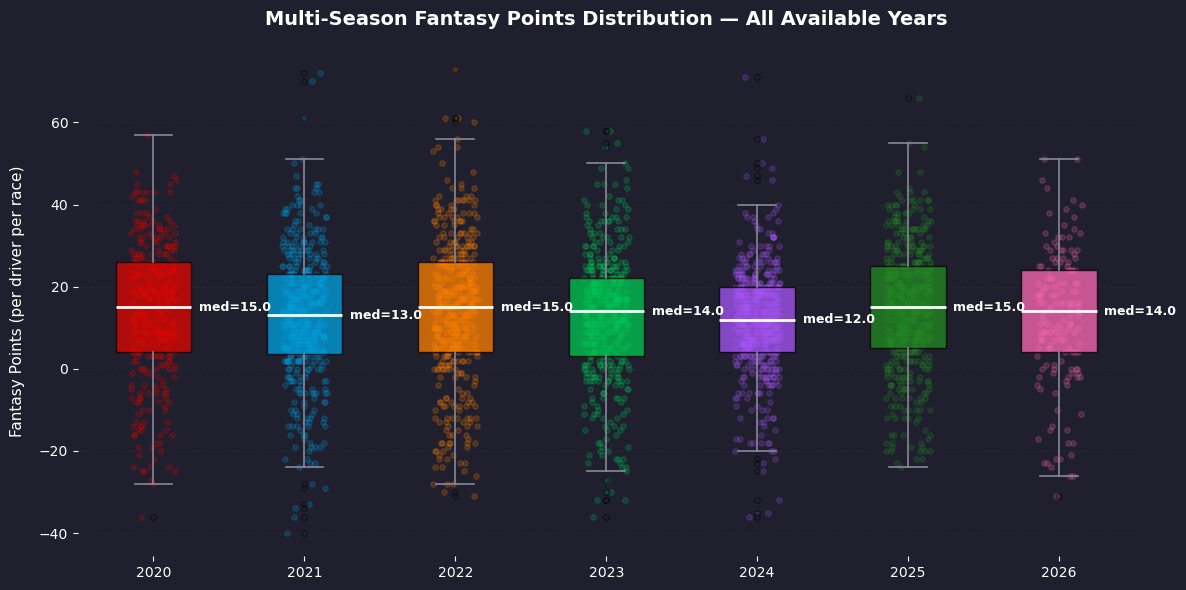

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = [master_pd[master_pd["year"] == y]["fantasy_pts_total"].dropna() for y in available_years]
labels = [str(y) for y in available_years]

bp = ax.boxplot(
    plot_data, labels=labels, patch_artist=True, widths=0.5,
    medianprops=dict(color=F1_WHITE, linewidth=2),
    whiskerprops=dict(color="#888899", linewidth=1.2),
    capprops=dict(color="#888899", linewidth=1.2),
    flierprops=dict(marker="o", color=F1_AMBER, alpha=0.4, markersize=4),
    zorder=3,
)
for patch, yr in zip(bp["boxes"], available_years):
    patch.set_facecolor(YEAR_COLORS[yr])
    patch.set_alpha(0.75)

for i, (data, yr) in enumerate(zip(plot_data, available_years), 1):
    jitter = np.random.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(np.full(len(data), i) + jitter, data, alpha=0.2, s=15, color=YEAR_COLORS[yr], zorder=2)
    if len(data) > 0:
        med = data.median()
        ax.text(i + 0.3, med, f"med={med:.1f}", va="center", fontsize=9, color=F1_WHITE, fontweight="bold")

ax.set_ylabel("Fantasy Points (per driver per race)", labelpad=10, fontsize=11)
ax.set_title("Multi-Season Fantasy Points Distribution — All Available Years", fontsize=14, fontweight="bold", pad=15)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, zorder=0)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()


rolling fantasy points side by side w top 5 drivers

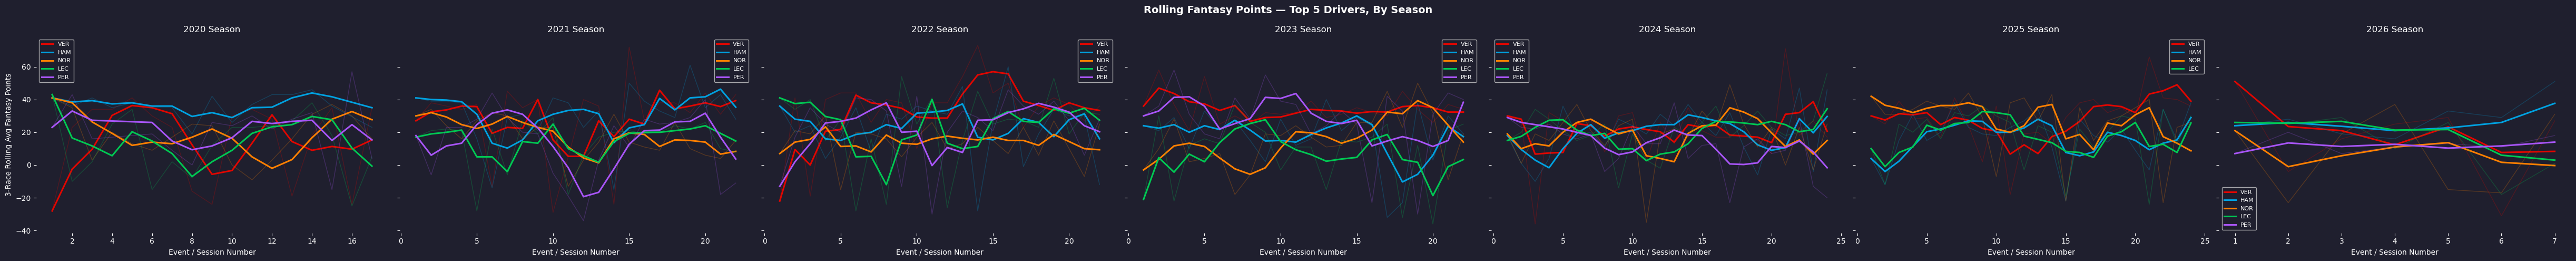

In [25]:
top5 = master_pd.groupby(driver_col)["fantasy_pts_total"].sum().nlargest(5).index.tolist()
palette = colors_cycle[:5]

fig, axes = plt.subplots(1, len(available_years), figsize=(7 * len(available_years), 5), sharey=True)
if len(available_years) == 1:
    axes = [axes]

for ax, year in zip(axes, available_years):
    year_data = master_pd[master_pd["year"] == year]
    for driver, color in zip(top5, palette):
        driver_data = year_data[year_data[driver_col] == driver].sort_values("session_number")
        if len(driver_data) == 0:
            continue
        ax.plot(driver_data["session_number"], driver_data["fantasy_pts_total"], color=color, alpha=0.25, linewidth=1)
        rolling = driver_data["fantasy_pts_total"].rolling(3, min_periods=1).mean()
        ax.plot(driver_data["session_number"], rolling, color=color, linewidth=2.2, label=driver)
    ax.set_title(f"{year} Season", color=F1_WHITE)
    ax.set_xlabel("Event / Session Number")
    ax.legend(fontsize=8, frameon=True, facecolor=F1_DARK)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

axes[0].set_ylabel("3-Race Rolling Avg Fantasy Points")
fig.suptitle("Rolling Fantasy Points — Top 5 Drivers, By Season", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


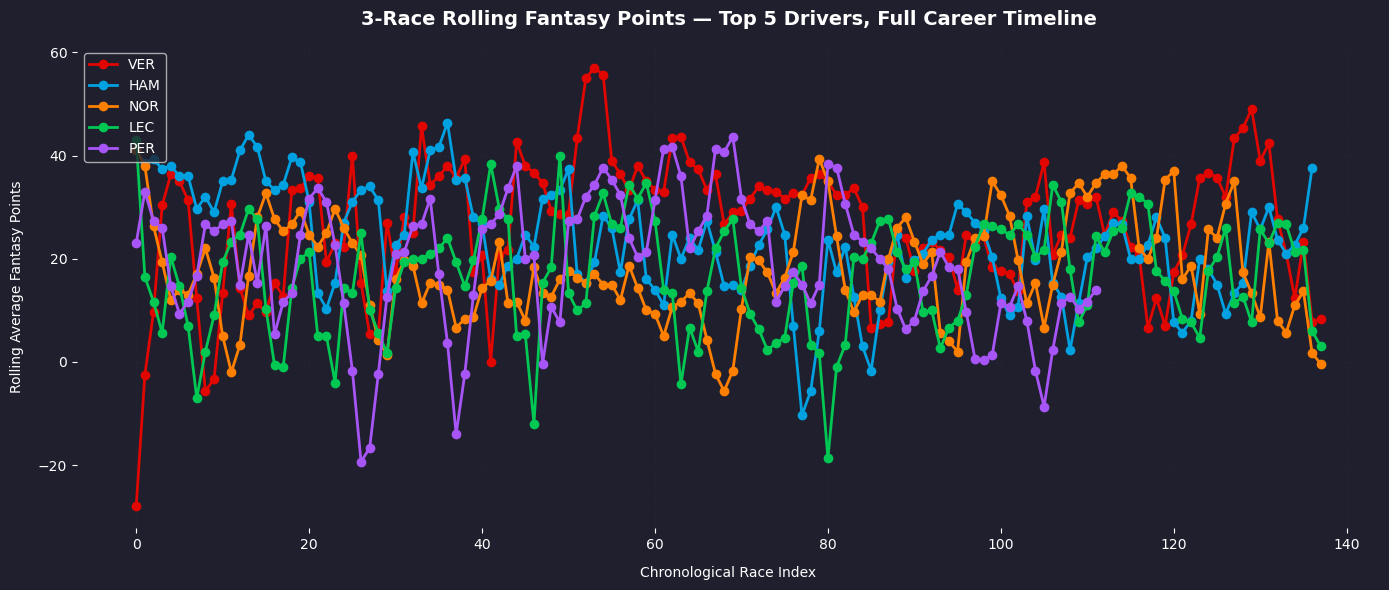

In [26]:
trend_df = master_pd[master_pd[driver_col].isin(top5)].copy()
trend_df = trend_df.sort_values(by=[driver_col, "year", "session_number"])
trend_df["rolling_avg"] = trend_df.groupby(driver_col)["fantasy_pts_total"].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(14, 6))
for driver, color in zip(top5, palette):
    driver_data = trend_df[trend_df[driver_col] == driver]
    ax.plot(range(len(driver_data)), driver_data["rolling_avg"], marker="o", linewidth=2, label=str(driver), color=color)

ax.set_title("3-Race Rolling Fantasy Points — Top 5 Drivers, Full Career Timeline", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Rolling Average Fantasy Points", labelpad=10)
ax.set_xlabel("Chronological Race Index", labelpad=10)
ax.legend(loc="upper left", frameon=True, facecolor=F1_DARK)
ax.grid(True, linestyle="--", alpha=0.2)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

pts by driver stacked by year

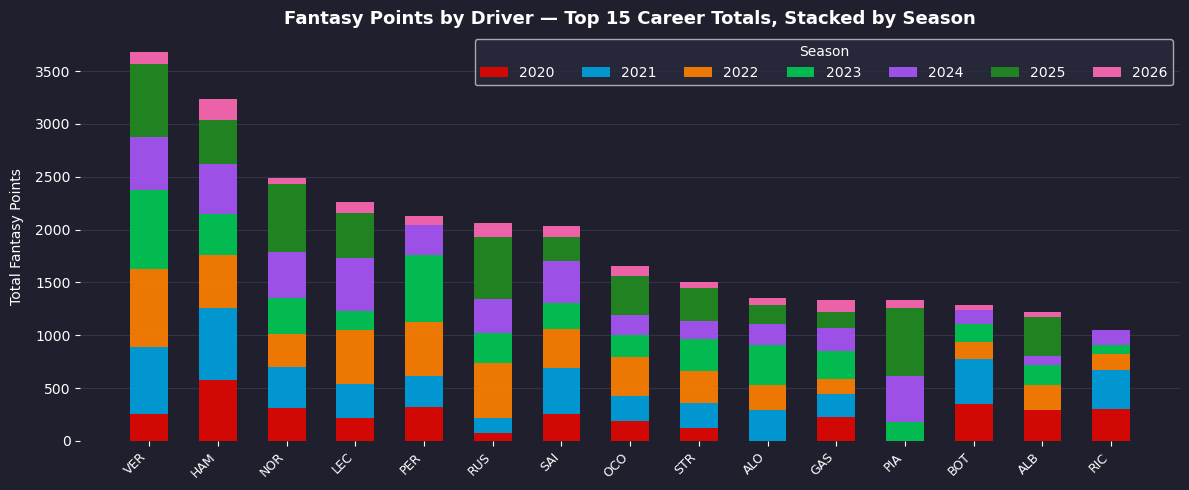

In [27]:
pts_by_driver = master_pd.groupby([driver_col, "year"])["fantasy_pts_total"].sum().reset_index()
pivot = pts_by_driver.pivot(index=driver_col, columns="year", values="fantasy_pts_total").fillna(0)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.nlargest(15, "total").drop(columns="total")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(pivot))
width = 0.55
bottom = np.zeros(len(pivot))

for year in sorted(pivot.columns):
    vals = pivot[year].values
    ax.bar(x, vals, width, bottom=bottom, color=YEAR_COLORS[year], label=str(year), alpha=0.92, zorder=3)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=9, rotation=45, ha="right")
ax.set_ylabel("Total Fantasy Points", labelpad=8)
ax.set_title("Fantasy Points by Driver — Top 15 Career Totals, Stacked by Season", fontsize=13, fontweight="bold")
ax.legend(title="Season", ncol=len(available_years))
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

overtakes by driver

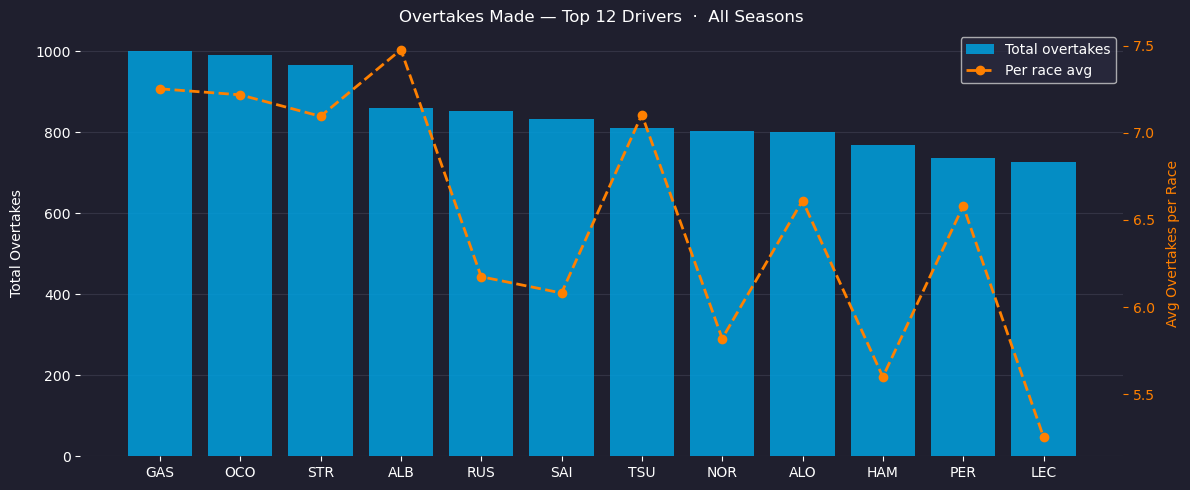

In [28]:
overtake_agg = (
    master_pd.groupby(driver_col)
    .agg(total_overtakes=("overtakes_made", "sum"), races=("overtakes_made", "count"))
    .assign(per_race=lambda d: d["total_overtakes"] / d["races"])
    .nlargest(12, "total_overtakes")
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(overtake_agg[driver_col], overtake_agg["total_overtakes"], color=F1_BLUE, alpha=0.85, zorder=3, label="Total overtakes")
ax2.plot(overtake_agg[driver_col], overtake_agg["per_race"], color=F1_AMBER, marker="o", linewidth=2,
         markersize=6, linestyle="--", zorder=4, label="Per race avg")

ax1.set_ylabel("Total Overtakes", labelpad=8)
ax2.set_ylabel("Avg Overtakes per Race", color=F1_AMBER, labelpad=8)
ax2.tick_params(axis="y", colors=F1_AMBER)
ax1.set_title("Overtakes Made — Top 12 Drivers  ·  All Seasons")
ax1.yaxis.grid(True, zorder=0); ax1.set_axisbelow(True)
ax1.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax2.spines[["top", "right", "left", "bottom"]].set_visible(False)

h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.tight_layout(); plt.show()


fantasy points breakdown

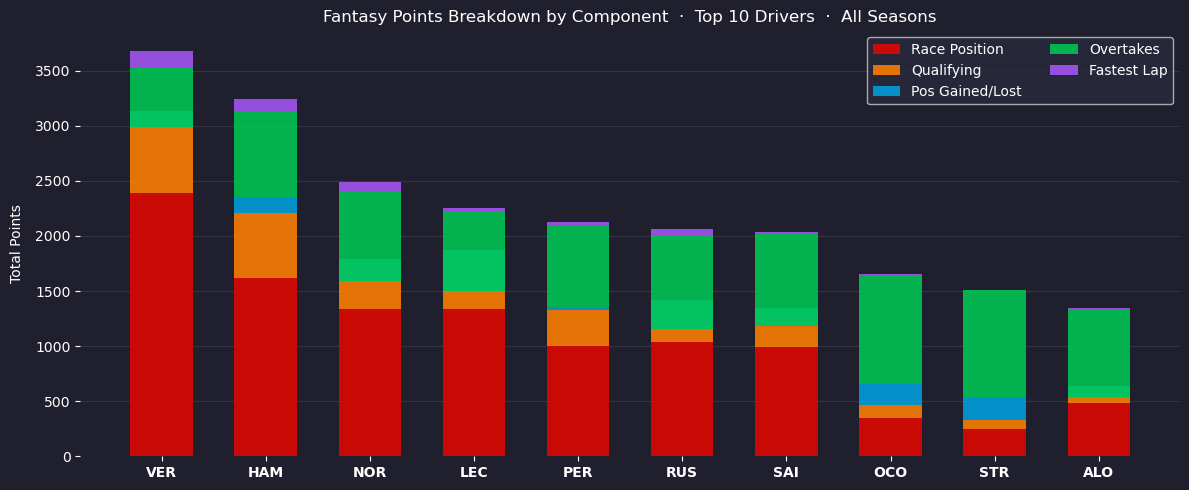

In [30]:
pt_cols = {
    "pts_race":     ("Race Position",   F1_RED),
    "pts_quali":    ("Qualifying",      F1_AMBER),
    "pts_pos":      ("Pos Gained/Lost", F1_BLUE),
    "pts_overtake": ("Overtakes",       "#00c853"),
    "pts_fastest":  ("Fastest Lap",     "#a855f7"),
}

breakdown = master_pd.groupby(driver_col)[list(pt_cols.keys())].sum()
breakdown["total"] = breakdown.sum(axis=1)
breakdown = breakdown.nlargest(10, "total").drop(columns="total")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(breakdown)); width = 0.6; bottom = np.zeros(len(breakdown))

for col_name, (label, color) in pt_cols.items():
    vals = breakdown[col_name].values
    ax.bar(x, vals, width, bottom=bottom, color=color, label=label, alpha=0.88, zorder=3)
    bottom += vals

ax.set_xticks(x); ax.set_xticklabels(breakdown.index, fontsize=10, fontweight="bold")
ax.set_ylabel("Total Points", labelpad=8)
ax.set_title("Fantasy Points Breakdown by Component  ·  Top 10 Drivers  ·  All Seasons")
ax.legend(loc="upper right", ncol=2)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()



median pit stop by team - not much here bc times are so close together

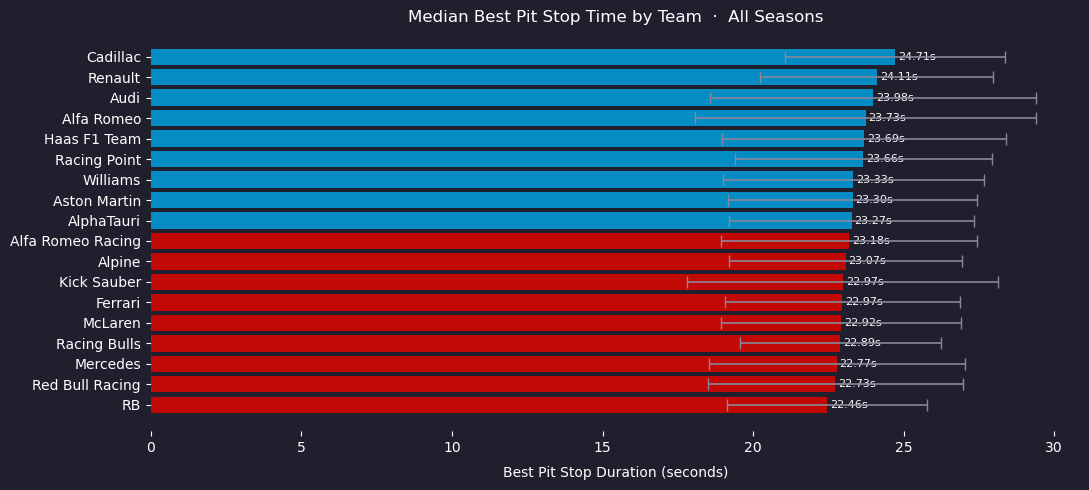

In [32]:
if team_col is not None and "best_pit_sec" in master_pd.columns:
    pit_valid = master_pd[master_pd["best_pit_sec"].between(1.8, 60)].copy()
    team_pit = (
        pit_valid.groupby(team_col)["best_pit_sec"]
        .agg(["median", "mean", "std", "count"])
        .sort_values("median")
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    overall_median = team_pit["median"].median()
    colors = [F1_RED if m < overall_median else F1_BLUE for m in team_pit["median"]]

    bars = ax.barh(team_pit[team_col], team_pit["median"], color=colors, alpha=0.85, zorder=3)
    ax.errorbar(team_pit["median"], team_pit[team_col], xerr=team_pit["std"], fmt="none",
                ecolor="#888899", capsize=4, linewidth=1.2, zorder=4)

    for bar, val in zip(bars, team_pit["median"]):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.2f}s", va="center", fontsize=8, color=F1_WHITE)

    ax.set_xlabel("Best Pit Stop Duration (seconds)", labelpad=8)
    ax.set_title("Median Best Pit Stop Time by Team  ·  All Seasons")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print("Skipping: team_col or best_pit_sec not available in master_pd.")


shocker - drivers that started behind the other gained more positions by the end.

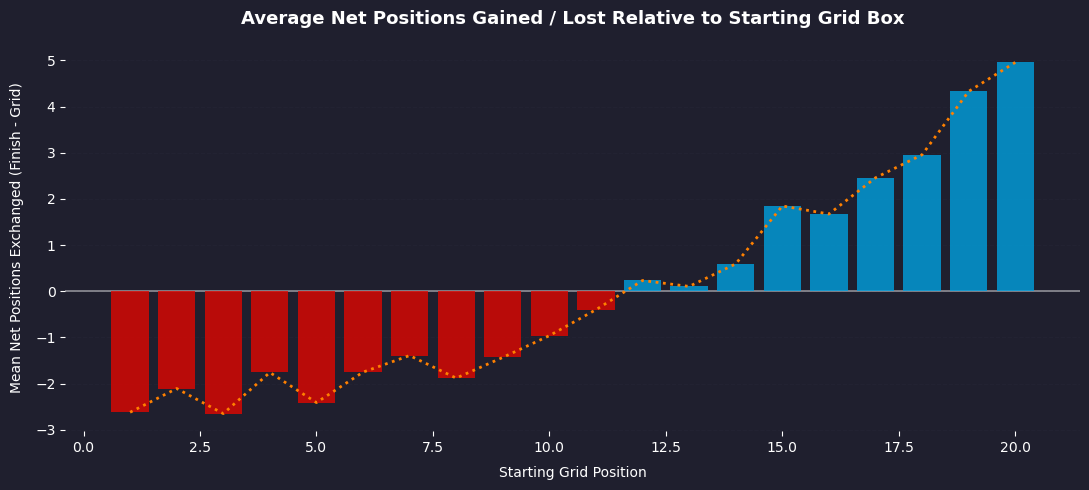

In [34]:
delta_summary = master_pd.groupby("GridPosition")["positions_gained"].mean().reset_index()
delta_summary = delta_summary[(delta_summary["GridPosition"] >= 1) & (delta_summary["GridPosition"] <= 20)]

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [F1_BLUE if val >= 0 else F1_RED for val in delta_summary["positions_gained"]]
ax.bar(delta_summary["GridPosition"].astype(int), delta_summary["positions_gained"], color=bar_colors, alpha=0.8, zorder=3)
ax.axhline(0, color=F1_WHITE, linewidth=1.2, alpha=0.5, zorder=2)
ax.plot(delta_summary["GridPosition"], delta_summary["positions_gained"], color=F1_AMBER, linestyle=":", linewidth=2, zorder=4)

ax.set_title("Average Net Positions Gained / Lost Relative to Starting Grid Box", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Starting Grid Position", labelpad=8)
ax.set_ylabel("Mean Net Positions Exchanged (Finish - Grid)", labelpad=8)
ax.yaxis.grid(True, linestyle="--", alpha=0.2, zorder=0)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

/tmp/ipykernel_187398/3279450472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=v_df, x=driver_col, y="fantasy_pts_total", ax=ax, palette="muted", linewidth=1.2)


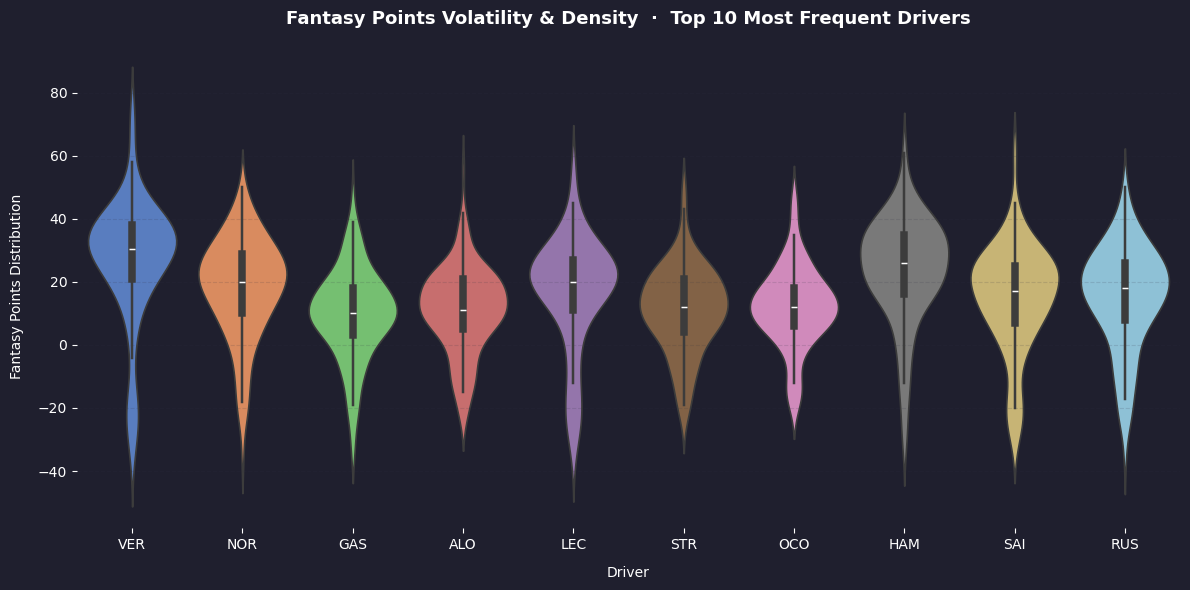

In [37]:
top_10_drivers = master_pd[driver_col].value_counts().nlargest(10).index.tolist()
v_df = master_pd[master_pd[driver_col].isin(top_10_drivers)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=v_df, x=driver_col, y="fantasy_pts_total", ax=ax, palette="muted", linewidth=1.2)
ax.set_title("Fantasy Points Volatility & Density  ·  Top 10 Most Frequent Drivers", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Driver", labelpad=10); ax.set_ylabel("Fantasy Points Distribution", labelpad=10)
ax.yaxis.grid(True, linestyle="--", alpha=0.15)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()


In [ ]:
looking at correlations between predictors

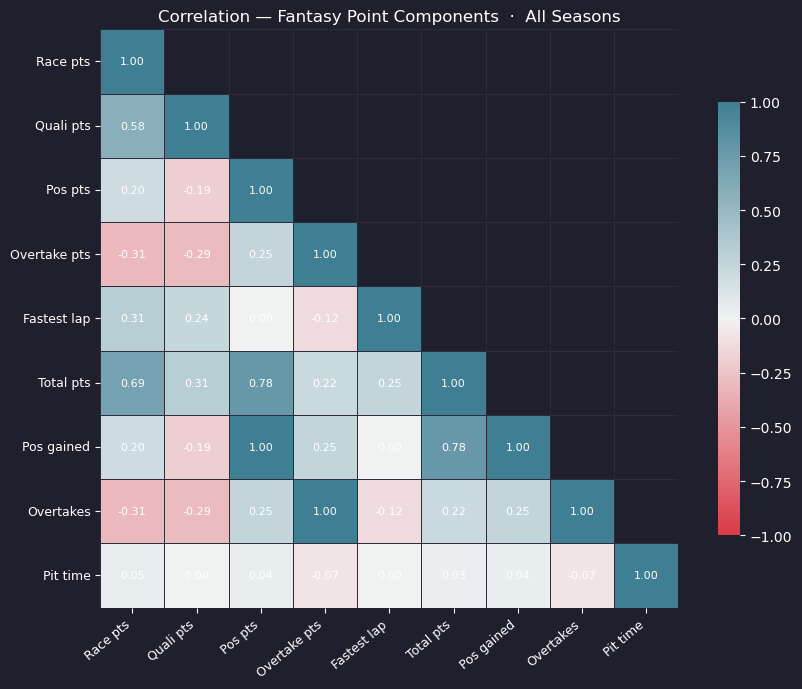

In [40]:
corr_cols = ["pts_race", "pts_quali", "pts_pos", "pts_overtake", "pts_fastest",
             "fantasy_pts_total", "positions_gained", "overtakes_made", "best_pit_sec"]
corr_cols = [c for c in corr_cols if c in master_pd.columns]
corr_labels = {
    "pts_race": "Race pts", "pts_quali": "Quali pts", "pts_pos": "Pos pts",
    "pts_overtake": "Overtake pts", "pts_fastest": "Fastest lap",
    "fantasy_pts_total": "Total pts", "positions_gained": "Pos gained",
    "overtakes_made": "Overtakes", "best_pit_sec": "Pit time",
}

corr_df = master_pd[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(10, 220, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 8, "color": "white"},
            linewidths=0.5, linecolor="#2c2c3a", cbar_kws={"shrink": 0.75}, ax=ax, square=True)
ax.set_xticklabels([corr_labels[c] for c in corr_cols], rotation=40, ha="right", fontsize=9)
ax.set_yticklabels([corr_labels[c] for c in corr_cols], rotation=0, fontsize=9)
ax.set_title("Correlation — Fantasy Point Components  ·  All Seasons")
plt.tight_layout(); plt.show()


correlation with fantasy points

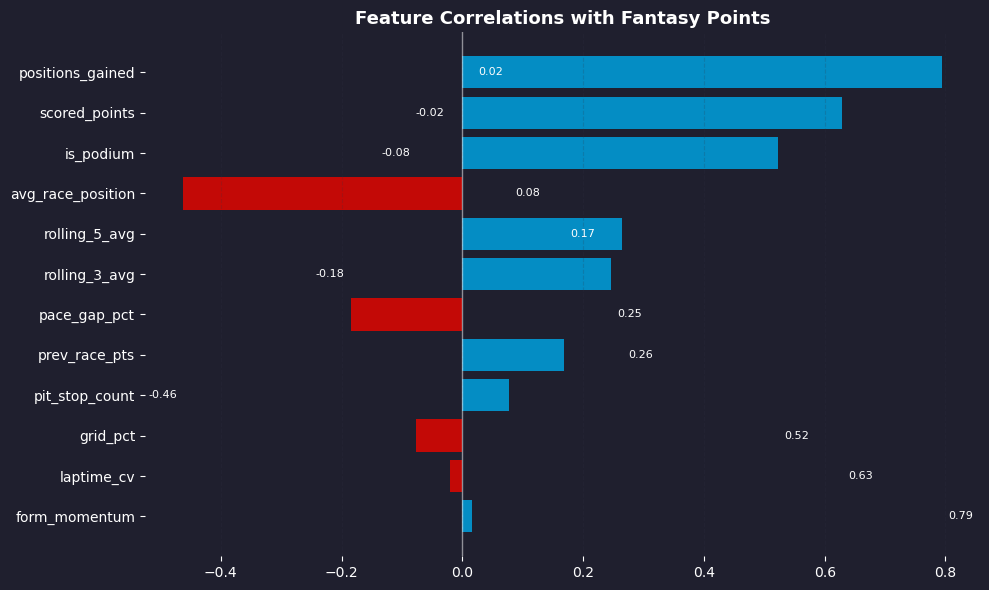

Ranked features (by |correlation| with fantasy_pts_total):
positions_gained     0.794320
scored_points        0.629368
is_podium            0.522860
avg_race_position   -0.462749
rolling_5_avg        0.264380
rolling_3_avg        0.246435
pace_gap_pct        -0.184960
prev_race_pts        0.168977
pit_stop_count       0.077702
grid_pct            -0.076768
laptime_cv          -0.019975
form_momentum        0.015841
Name: fantasy_pts_total, dtype: float64


In [41]:
TARGET = "fantasy_pts_total"
candidate_feats = [
    "positions_gained", "pace_gap_pct", "laptime_cv", "rolling_3_avg",
    "form_momentum", "pit_stop_count", "avg_race_position", "grid_pct",
    "scored_points", "is_podium", "rolling_5_avg", "prev_race_pts",
]
FEATS = [f for f in candidate_feats if f in master_pd.columns and master_pd[f].notna().sum() >= 30]

pearson_r = master_pd[FEATS + [TARGET]].dropna().corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [F1_BLUE if v >= 0 else F1_RED for v in pearson_r]
bars = ax.barh(pearson_r.index[::-1], pearson_r.values[::-1], color=bar_colors[::-1], alpha=0.85, edgecolor="none")
ax.axvline(0, color=F1_WHITE, lw=1, alpha=0.5)
for bar, val in zip(bars[::-1], pearson_r.values[::-1]):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=8, color=F1_WHITE)
ax.set_title("Feature Correlations with Fantasy Points", fontsize=13, fontweight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.2)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Ranked features (by |correlation| with fantasy_pts_total):")
print(pearson_r)

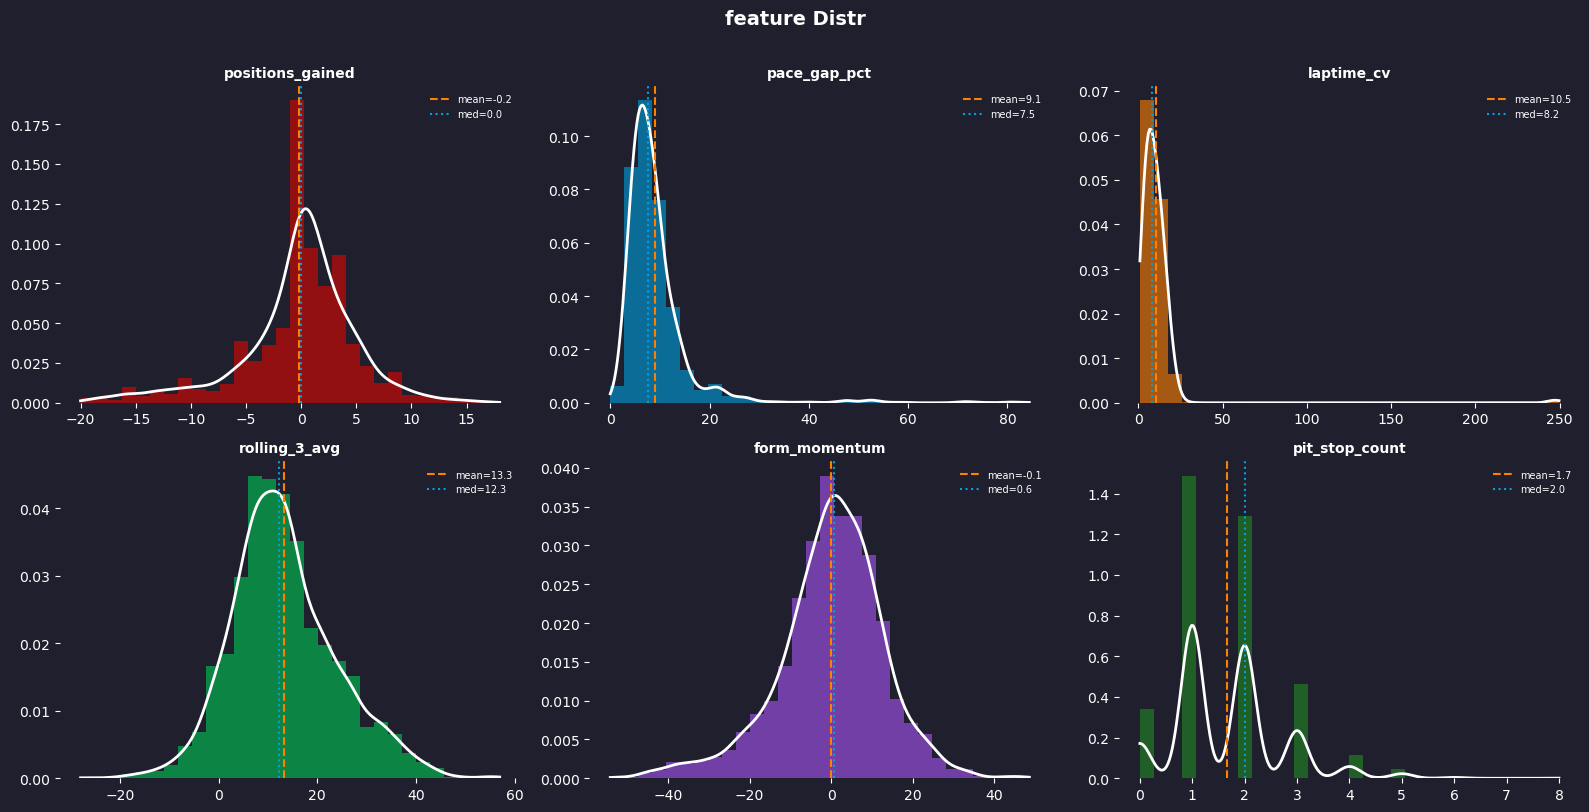

In [43]:
plot_feats = FEATS[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (ax, feat) in enumerate(zip(axes.flatten(), plot_feats)):
    data = master_pd[feat].dropna()
    ax.hist(data, bins=30, color=colors_cycle[i % len(colors_cycle)], alpha=0.6, density=True, edgecolor="none")
    kde_x = np.linspace(data.min(), data.max(), 300)
    ax.plot(kde_x, stats.gaussian_kde(data)(kde_x), color=F1_WHITE, lw=2)
    ax.axvline(data.mean(), color=F1_AMBER, lw=1.5, linestyle="--", label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color=F1_BLUE, lw=1.5, linestyle=":", label=f"med={data.median():.1f}")
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7, frameon=False)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
fig.suptitle("feature Distr", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

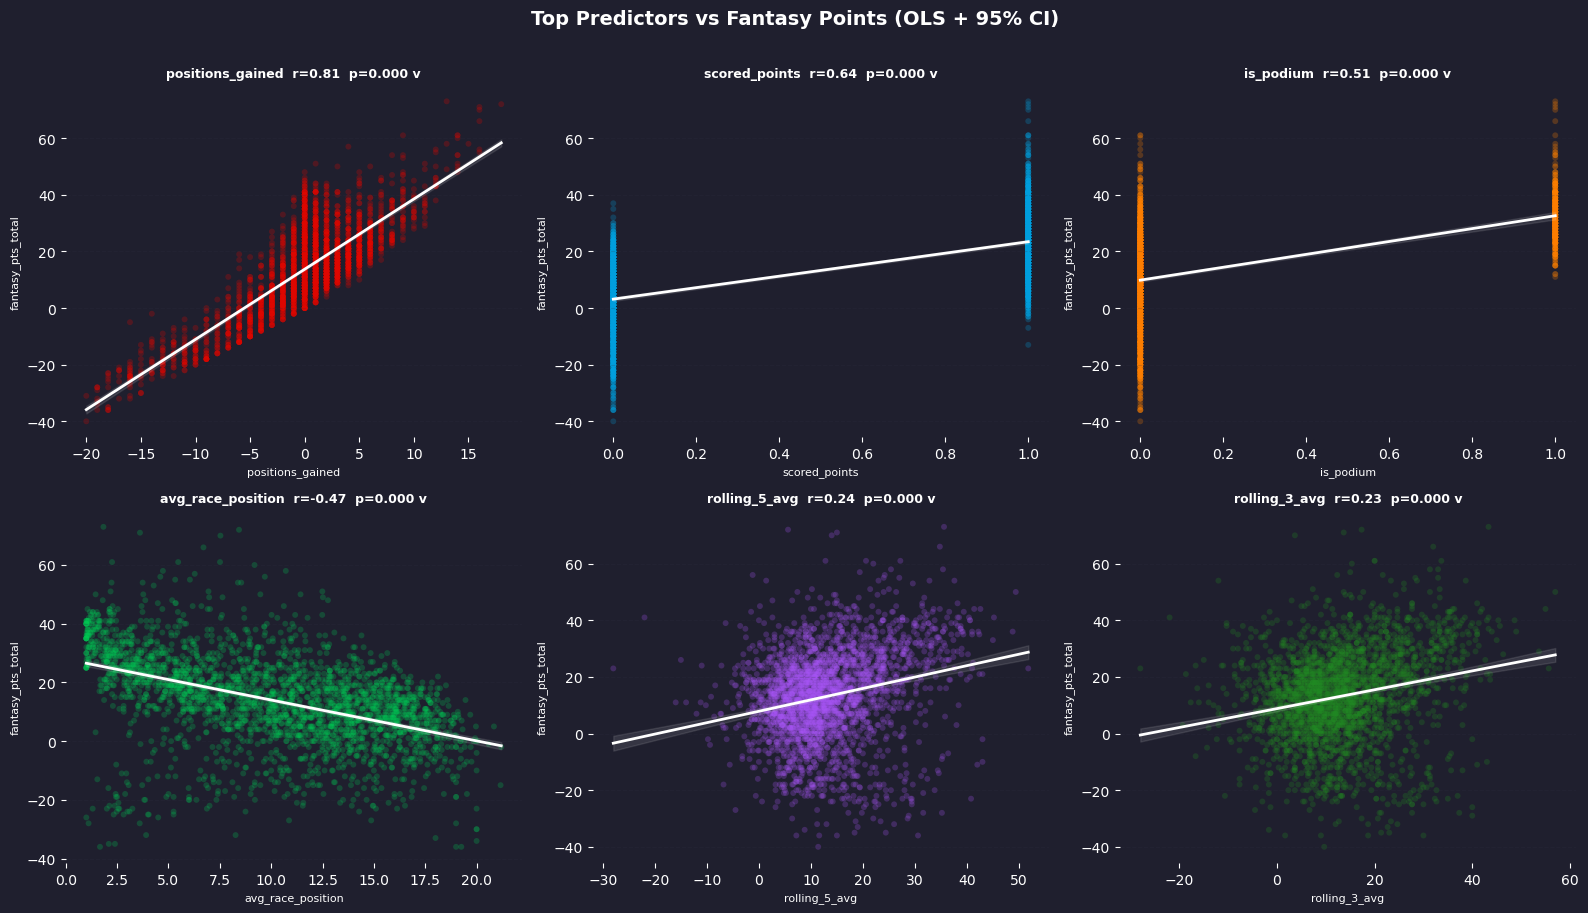

In [44]:
top6 = pearson_r.abs().nlargest(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, (ax, feat) in enumerate(zip(axes.flatten(), top6)):
    sub = master_pd[[feat, TARGET]].dropna()
    x, y = sub[feat].values, sub[TARGET].values
    ax.scatter(x, y, alpha=0.25, s=18, color=colors_cycle[i % len(colors_cycle)], edgecolors="none")
    m, b, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color=F1_WHITE, lw=2)
    n, xm = len(x), np.mean(x)
    ci = stats.t.ppf(0.975, n - 2) * np.sqrt(np.sum((y - (m * x + b)) ** 2) / (n - 2)) * \
         np.sqrt(1 / n + (x_line - xm) ** 2 / np.sum((x - xm) ** 2))
    ax.fill_between(x_line, m * x_line + b - ci, m * x_line + b + ci, color=F1_WHITE, alpha=0.1)
    ax.set_title(f"{feat}  r={r:.2f}  p={p:.3f} {'v' if p < 0.05 else 'x'}", fontsize=9, fontweight="bold")
    ax.set_xlabel(feat, fontsize=8); ax.set_ylabel(TARGET, fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.2)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
fig.suptitle("Top Predictors vs Fantasy Points (OLS + 95% CI)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

interesting find here- lap consistency doesnt appear to have much of an affect on fantasy points

/tmp/ipykernel_187398/191500143.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=sorted(pit["pit_stop_count"].unique()), patch_artist=True,
/tmp/ipykernel_187398/191500143.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cv, x="bucket", y=TARGET, order=order, ax=ax,


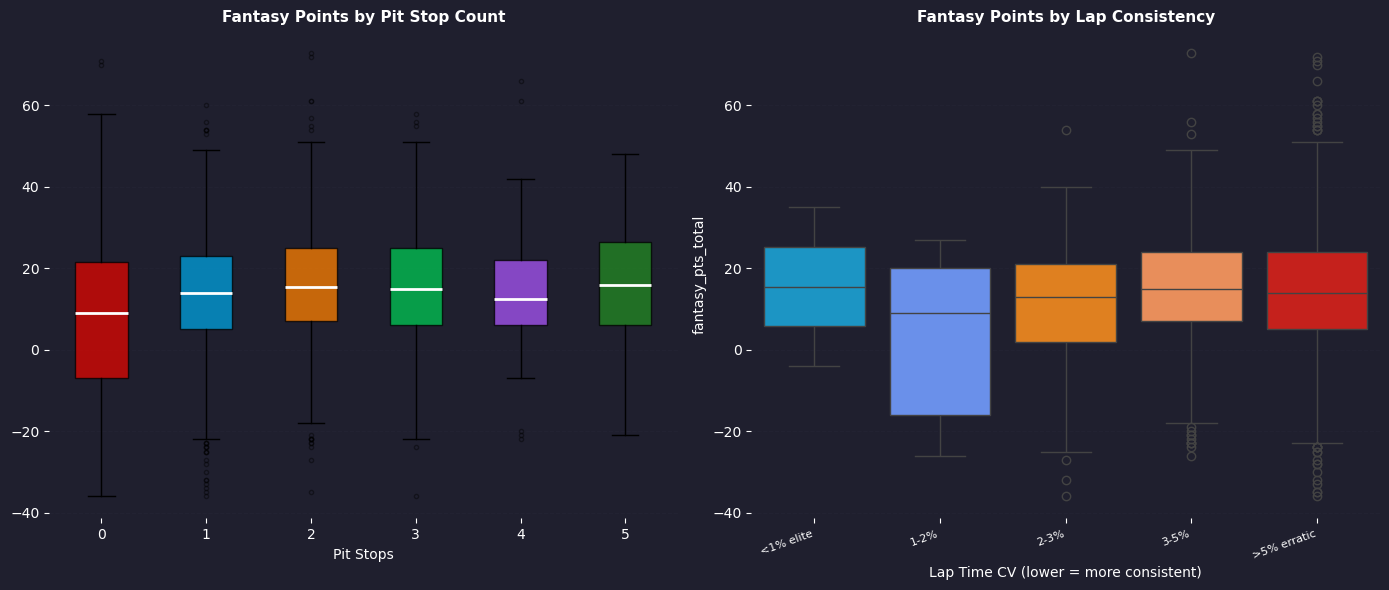

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
if "pit_stop_count" in master_pd.columns:
    pit = master_pd[["pit_stop_count", TARGET]].dropna().copy()
    pit["pit_stop_count"] = pit["pit_stop_count"].clip(0, 5).astype(int)
    groups = [pit[pit["pit_stop_count"] == k][TARGET].values for k in sorted(pit["pit_stop_count"].unique())]
    bp = ax.boxplot(groups, labels=sorted(pit["pit_stop_count"].unique()), patch_artist=True,
                    medianprops=dict(color=F1_WHITE, lw=2), flierprops=dict(marker=".", color=F1_AMBER, alpha=0.4))
    for patch, c in zip(bp["boxes"], colors_cycle):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_title("Fantasy Points by Pit Stop Count", fontsize=11, fontweight="bold")
    ax.set_xlabel("Pit Stops"); ax.yaxis.grid(True, linestyle="--", alpha=0.2)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

ax = axes[1]
if "laptime_cv" in master_pd.columns:
    cv = master_pd[["laptime_cv", TARGET]].dropna().copy()
    cv["bucket"] = pd.cut(cv["laptime_cv"], bins=[0, 1, 2, 3, 5, np.inf],
                          labels=["<1% elite", "1-2%", "2-3%", "3-5%", ">5% erratic"])
    order = ["<1% elite", "1-2%", "2-3%", "3-5%", ">5% erratic"]
    sns.boxplot(data=cv, x="bucket", y=TARGET, order=order, ax=ax,
                palette=[F1_BLUE, "#5588ff", F1_AMBER, "#ff8844", F1_RED])
    ax.set_title("Fantasy Points by Lap Consistency", fontsize=11, fontweight="bold")
    ax.set_xlabel("Lap Time CV (lower = more consistent)")
    ax.yaxis.grid(True, linestyle="--", alpha=0.2)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)

plt.tight_layout(); plt.show()

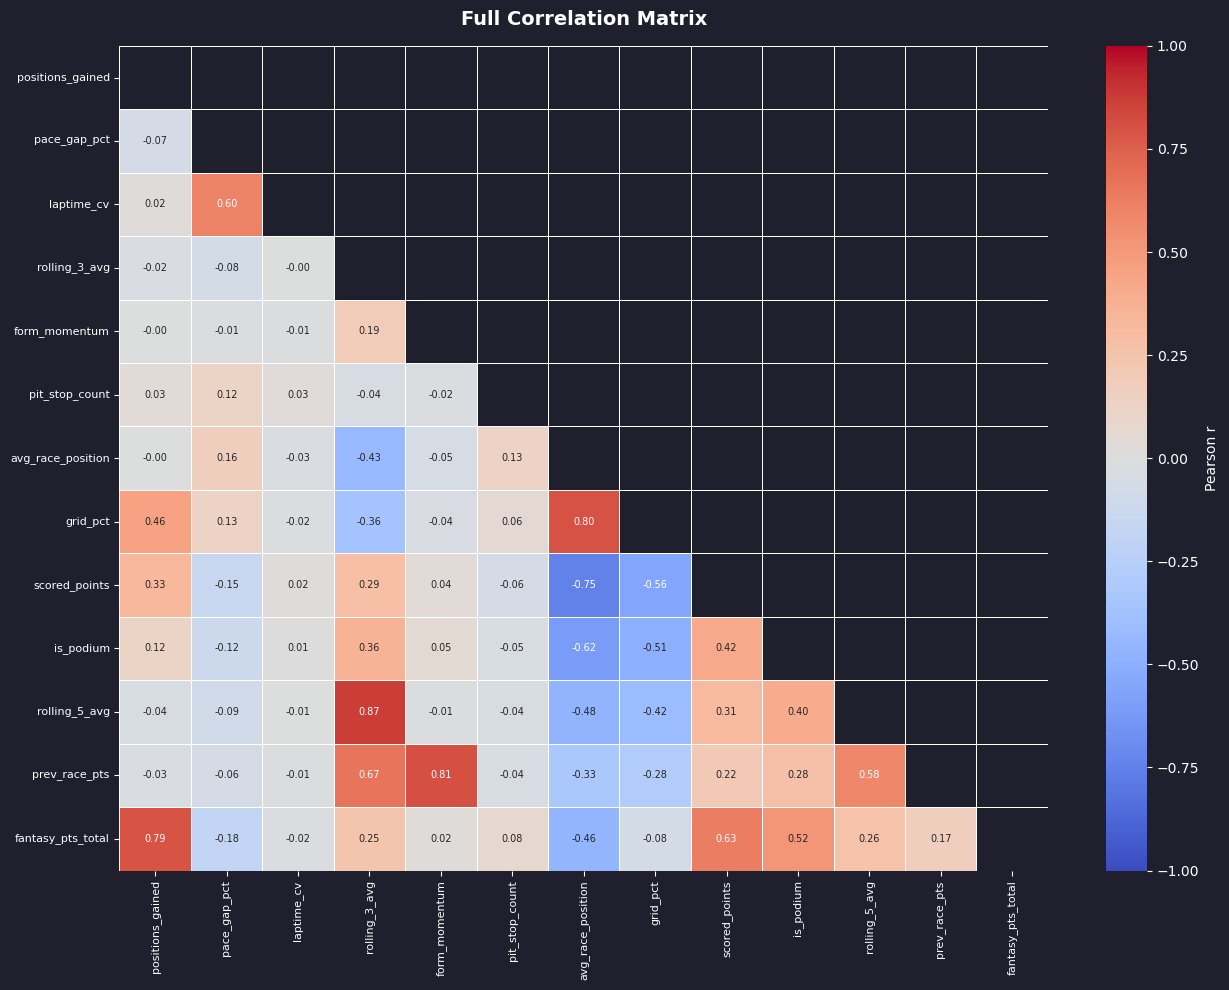

In [48]:
hm_df = master_pd[FEATS + [TARGET]].dropna()
corr = hm_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5,
            vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"})
ax.set_title("Full Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()